## Import Libraries

In [ ]:
import numpy as np
from scipy.integrate import quad
from scipy.special import erfc
from colossus.cosmology import cosmology

class HaloMassFunction:
    def __init__(self, omega_m=0.3089, z=0, mdef='m200b'):
        self.omega_m = omega_m
        self.z = z
        self.rho_crit = 277536627245.708  # M_sun / (h Mpc)^3
        self.rho_m = omega_m * self.rho_crit
        self.cosmo = cosmology.setCosmology('planck15')
        print(self.cosmo)
        self.D0 = self.D_unnormalized(0.0)
        self.pk_table_path = None#'power_uchuu_log10.dat'
        self.ps_args = dict(model='uchuu_table', path=self.pk_table_path) if self.pk_table_path else dict(model='camb')
        self.mdef = mdef
        
        if self.mdef == 'm200b':
            self.aa, self.bb, self.DD, self.EE, self.FF = 1.089, 0.652, 1.0, 0.17, 0.087

        else:
            raise ValueError(f"mdef '{self.mdef}' no válido. Usa 'm200b' o 'mvir'.")
    

    def RtoM(self, M):
        return (3 * M / (4 * np.pi * self.omega_m * self.rho_crit))**(1/3)

    def E(self, z):
        return np.sqrt(self.omega_m * (1 + z)**3 + (1 - self.omega_m))

    def D_unnormalized(self, z):
        integral, _ = quad(lambda zp: (1 + zp) / (self.E(zp)**3), z, np.inf)
        return (5 * self.omega_m * self.E(z) / 2) * integral

    def sigma(self, M):
        M = np.atleast_1d(M)
        R = self.RtoM(M)
        sigma_std = self.cosmo.sigma(R, self.z, ps_args=self.ps_args)
        x = sigma_std / 1.676
        U2 = (-0.00221 * x**3 + 0.03835 * x**2 + 0.17810 * x - 0.01507)**2
        sigma_mod = np.sqrt(sigma_std**2 + U2)
        return sigma_mod[0] if np.isscalar(M) else sigma_mod

    def b(self, m_val):
        m = np.array([1e16, 1e15, 1e14, 6.5e10, 1e10, 1e9, 1e8, 1e7, 1e6])
        b = np.array([0.5259, 0.415, 0.328, 0.1764, 0.1552, 0.1308, 0.1179, 0.1045, 0.094])
        coeffs = np.polyfit(np.log10(m), np.log10(b), 4)
        return 10**np.polyval(coeffs, np.log10(m_val))

    def c(self, m_val):
        m = np.array([3e15, 3e14, 3e13, 3e12, 3e11, 3e10, 3e9, 3e8, 3e7, 3e6, 1e10, 1e9, 1e8, 1e7, 1e6])
        b = np.array([0.613, 0.474, 0.373, 0.301, 0.249, 0.209, 0.1794, 0.1560, 0.1355, 0.1223, 0.1942, 0.168, 0.1466, 0.1298, 0.1161])
        coeffs = np.polyfit(np.log10(m), np.log10(b), 4)
        return 10**np.polyval(coeffs, np.log10(m_val))

    def F(self, m_array):
        m_array = np.atleast_1d(m_array)  
        R = self.RtoM(m_array)
        b_val = self.b(m_array)
        sig = self.sigma(m_array)
        x = self.cosmo.sigma(R, self.z, ps_args=self.ps_args) / 1.676

        term1 = (1 + 0.845*x - 0.04*x**2 + 0.0025*x**3)**self.bb
        term2 = self.aa * 1.365 * (1 + self.EE * b_val - self.FF * b_val**2)**self.DD
        delta_c = term1 * term2

        c_m = self.c(m_array)
        cte = delta_c / (np.sqrt(2) * sig)

        xi = np.linspace(0, 1, 1000) 
        xi2 = xi**2
        xi_mat = xi[np.newaxis, :]
        c_m_mat = c_m[:, np.newaxis]
        cte_mat = cte[:, np.newaxis]
        integrand = erfc(cte_mat * np.sqrt((1 - np.exp(-c_m_mat * xi_mat**2)) / (1 + np.exp(-c_m_mat * xi_mat**2)))) * xi2
        I = np.trapz(integrand, xi, axis=1)
        V = 3 * I

        F_val = erfc(0.98 * cte) / V
        return F_val if F_val.size > 1 else F_val[0]

    def n0(self, m): ##this gives dn/dlnM
        s = 0.01
        Fm = self.F(m)
        Fm_s = self.F((1 + s) * m)
        der = (Fm - Fm_s) / s
        return der * self.rho_m / (m * (1 + s/2))

In [4]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
from galform_analysis.analysis.mass_functions import (
    hmf_given_redshift_and_subvolume,
    compute_theoretical_hmfs,
    plot_single_hmf_given_redshift_and_subvolume,
    plot_hmf_with_theory,
    plot_hmf_multiple_redshifts,
)
from galform_analysis.analysis import hmfs_given_redshifts_and_subvolume

from hmf import MassFunction

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = get_base_dir()

##  GPS+ via HMF_GPSplus

Use the public implementation from https://github.com/uchuuproject/HMF_GPSplus.
We wrap `HaloMassFunction` for convenience and align mass definitions (m200b) when comparing to Tinker08 (SOMean-200).

In [6]:
import numpy as np
#from HMF import HaloMassFunction

# Wrapper to match previous signature but using HMF_GPSplus
# Returns: M, dn/dlog10M

def gps_plus_hmf(z=0.0, mmin=9.0, mmax=15.0, dlog10m=0.01, mdef='m200b'):
    """
    GPS+ HMF via HMF_GPSplus HaloMassFunction.
    - z: redshift
    - mdef: mass definition ('m200b' or 'mvir')
    - mmin/mmax: log10 mass bounds (M_sun/h)
    - dlog10m: log10 mass step
    Returns mass array and dn/dlog10M.
    """
    log10M = np.arange(mmin, mmax + dlog10m/2.0, dlog10m)
    M = 10**log10M
    hmf_model = HaloMassFunction(z=z, mdef=mdef)
    dn_dlnM = hmf_model.n0(M)  # dn/dlnM
    dndlog10m = dn_dlnM * np.log(10.0)
    return M, dndlog10m

# Replicating Paper Figures

Reproduce key figures from Fernández-García et al. (2025) using our GPS+ implementation

## Figure 1: Multiplicity Function f(σ,M) vs Mass

Paper shows GPS+ multiplicity function compared to simulations across different redshifts

Cosmology "planck15" 
    flat = True, Om0 = 0.3089, Ode0 = 0.6910, Ob0 = 0.0486, H0 = 67.74, sigma8 = 0.8159, ns = 0.9667
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


Exception: File power_uchuu_log10.dat not found.

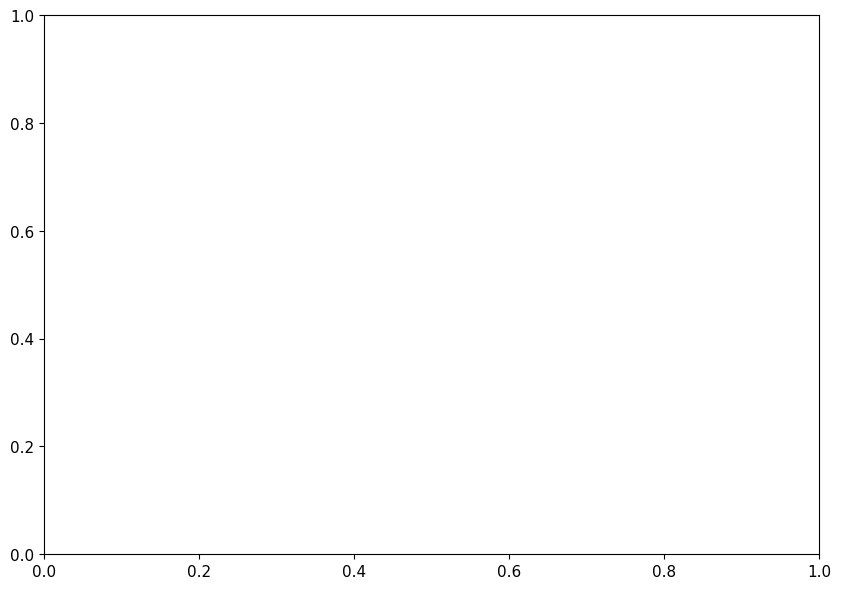

In [7]:
# Figure 1: Multiplicity function f(σ,M) across redshifts
# Paper's Equation 1: f(M,z) = log10(M²/ρ_m * dn/dM * |dlnM/dlnσ|)

# Redshifts from paper
redshifts = [0.0, 1.0, 2.0, 3.0, 4.0, 6.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(redshifts)))

fig, ax = plt.subplots(figsize=(10, 7))

for z, color in zip(redshifts, colors):
    # Compute GPS+ at this redshift (m200b)
    M_gps, dn_dlog10m_gps = gps_plus_hmf(z=z, mmin=6.0, mmax=16.0, dlog10m=0.05, mdef='m200b')
    
    # Get sigma and compute multiplicity function from hmf
    hmf_calc = MassFunction(z=z, Mmin=6.0, Mmax=16.0, dlog10m=0.05)
    sigma_z = hmf_calc.sigma
    rho_m_z = hmf_calc.mean_density0
    
    # Convert dn/dlog10M to dn/dM
    dn_dM = dn_dlog10m_gps * np.log(10.0) / M_gps
    
    # Compute |dlnM/dlnσ|
    lnM_z = np.log(M_gps)
    lnsigma_z = np.log(sigma_z)
    dlnM_dlnsigma_z = np.abs(np.gradient(lnM_z, lnsigma_z))
    
    # Multiplicity function from Equation 1
    f_mult = (M_gps**2 / rho_m_z) * dn_dM * dlnM_dlnsigma_z
    
    # Plot
    log10M_z = np.log10(M_gps)
    ax.plot(log10M_z, np.log10(f_mult), color=color, lw=2, label=f'z={z:.1f}')

ax.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax.set_ylabel('log₁₀(f(M,z))', fontsize=14)
ax.set_title('GPS+ Multiplicity Function (HMF_GPSplus)', fontsize=15, fontweight='bold')
ax.set_xlim([6, 16])
ax.set_ylim([-6, 0])
#ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Figure 1: Multiplicity function across redshifts (GPS+ via HMF_GPSplus)")
print("Note: Paper shows this is nearly redshift-independent")
print(f"Our GPS+ f(M) range: {f_mult.min():.3f} - {f_mult.max():.3f}")

## Figure 2: Multiplicity function f(σ,z) as a function of σ at different redshifts

/tmp/ipykernel_3566348/3364068870.py:40: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(1/sigma_z), np.log10(f_mult), color=color, lw=2, label=f'z={z:.1f}', marker='o', markersize=4)
/tmp/ipykernel_3566348/3364068870.py:46: RuntimeWarning: divide by zero encountered in log10
  ratio = np.log10(f_mult) - f_z0_interp  # In log space: log(f(z)) - log(f(z=0)) = log(ratio)


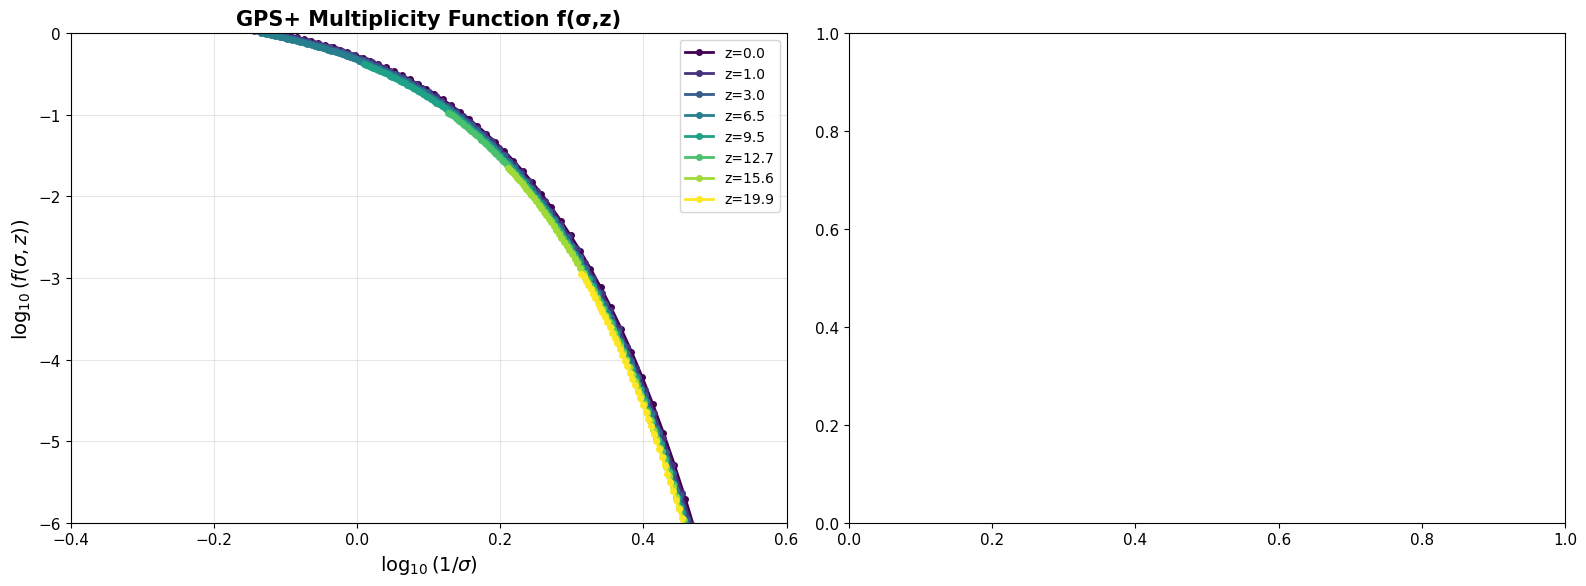

Figure 2: Multiplicity function as function of σ
Note: Paper shows this is nearly redshift-independent
Our GPS+ f(σ) range: -0.000 - 0.001
Right panel shows redshift evolution: ratio should be close to 1 (f independent of z)


In [ ]:
# Figure 2: Multiplicity function f(σ,z) as a function of σ at different redshifts
# Paper's Equation 1: f(M,z) = M²/ρ_m * dn/dM * |dlnM/dlnσ|

# Redshifts from paper
redshifts_fig2 = [0.0, 1.03, 2.95, 6.53, 9.47, 12.69, 15.57, 19.95]
colors_fig2 = plt.cm.viridis(np.linspace(0, 1, len(redshifts_fig2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dictionary to store z=0 data for ratio calculation
f_mult_z0 = None
sigma_z0 = None

for z, color in zip(redshifts_fig2, colors_fig2):
    # Compute GPS+ at this redshift (m200b)
    M_gps, dn_dlog10m_gps = gps_plus_hmf(z=z, mmin=6.0, mmax=16.0, dlog10m=0.05, mdef='m200b')
    
    # Get sigma and compute multiplicity function
    hmf_calc = MassFunction(z=z, Mmin=6.0, Mmax=16.0, dlog10m=0.05)
    sigma_z = hmf_calc.sigma
    rho_m_z = hmf_calc.mean_density0
    
    # Convert dn/dlog10M to dn/dM
    dn_dM = dn_dlog10m_gps * np.log(10.0) / M_gps
    
    # Compute |dlnM/dlnσ|
    lnM_z = np.log(M_gps)
    lnsigma_z = np.log(sigma_z)
    dlnM_dlnsigma_z = np.abs(np.gradient(lnM_z, lnsigma_z))
    
    # Multiplicity function from Equation 1
    f_mult = (M_gps**2 / rho_m_z) * dn_dM * dlnM_dlnsigma_z
    
    # Store z=0 data for ratio calculation
    if z == 0.0:
        f_mult_z0 = f_mult.copy()
        sigma_z0 = sigma_z.copy()
    
    # Left panel: Plot f as a function of σ (not M)
    ax1.plot(np.log10(1/sigma_z), np.log10(f_mult), color=color, lw=2, label=f'z={z:.1f}', marker='o', markersize=4)
    
    # Right panel: Plot ratio f(z)/f(z=0) as a function of 1/σ
    if f_mult_z0 is not None and z != 0.0:
        # Interpolate f(z=0) to the same sigma grid as f(z)
        f_z0_interp = np.interp(np.log10(sigma_z), np.log10(sigma_z0), np.log10(f_mult_z0))
        ratio = np.log10(f_mult) - f_z0_interp  # log space
        # ax2.plot(np.log10(1/sigma_z), ratio, color=color, lw=2, label=f'z={z:.1f}', marker='o', markersize=4)

# Configure left panel
ax1.set_xlabel(r'$\\log_{10}(1/\\sigma)$', fontsize=14)
ax1.set_ylabel(r'$\\log_{10}(f(\\sigma,z))$', fontsize=14)
ax1.set_title('GPS+ Multiplicity Function f(σ,z)', fontsize=15, fontweight='bold')
ax1.set_xlim([-0.4, 0.6])
ax1.set_ylim([-6, 0])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# # Configure right panel (optional)
# ax2.axhline(0.0, color='black', ls='--', lw=1.5, alpha=0.7, label='f(z=0)')
# ax2.set_xlabel(r'$\\log_{10}(1/\\sigma)$', fontsize=14)
# ax2.set_ylabel(r'$\\log_{10}(f(\\sigma,z) / f(\\sigma,z=0))$', fontsize=14)
# ax2.set_title('Redshift Evolution of f(σ,z) / f(σ,z=0)', fontsize=15, fontweight='bold')
# ax2.set_xlim([-0.4, 0.6])
# ax2.set_ylim([0.5, 2])
# ax2.legend(loc='best', fontsize=10)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 2: Multiplicity function as function of σ (GPS+ via HMF_GPSplus)")
print("Note: Paper shows this is nearly redshift-independent")
print(f"Our GPS+ f(σ) last computed range: {f_mult.min():.3f} - {f_mult.max():.3f}")
print("Right panel omitted by default; uncomment to visualize ratios.")

## Figure 3: GPS+/Tinker08 Ratio vs Redshift

Paper shows GPS+ agreement with Tinker08 is consistent across z=0-6 for different mass bins

/cosma/home/durham/dc-hick2/galform_analysis/.venv/lib64/python3.9/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(
/tmp/ipykernel_3594016/3667142675.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = dn_gps / dn_tinker_interp
/tmp/ipykernel_3594016/3667142675.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = dn_gps / dn_tinker_interp


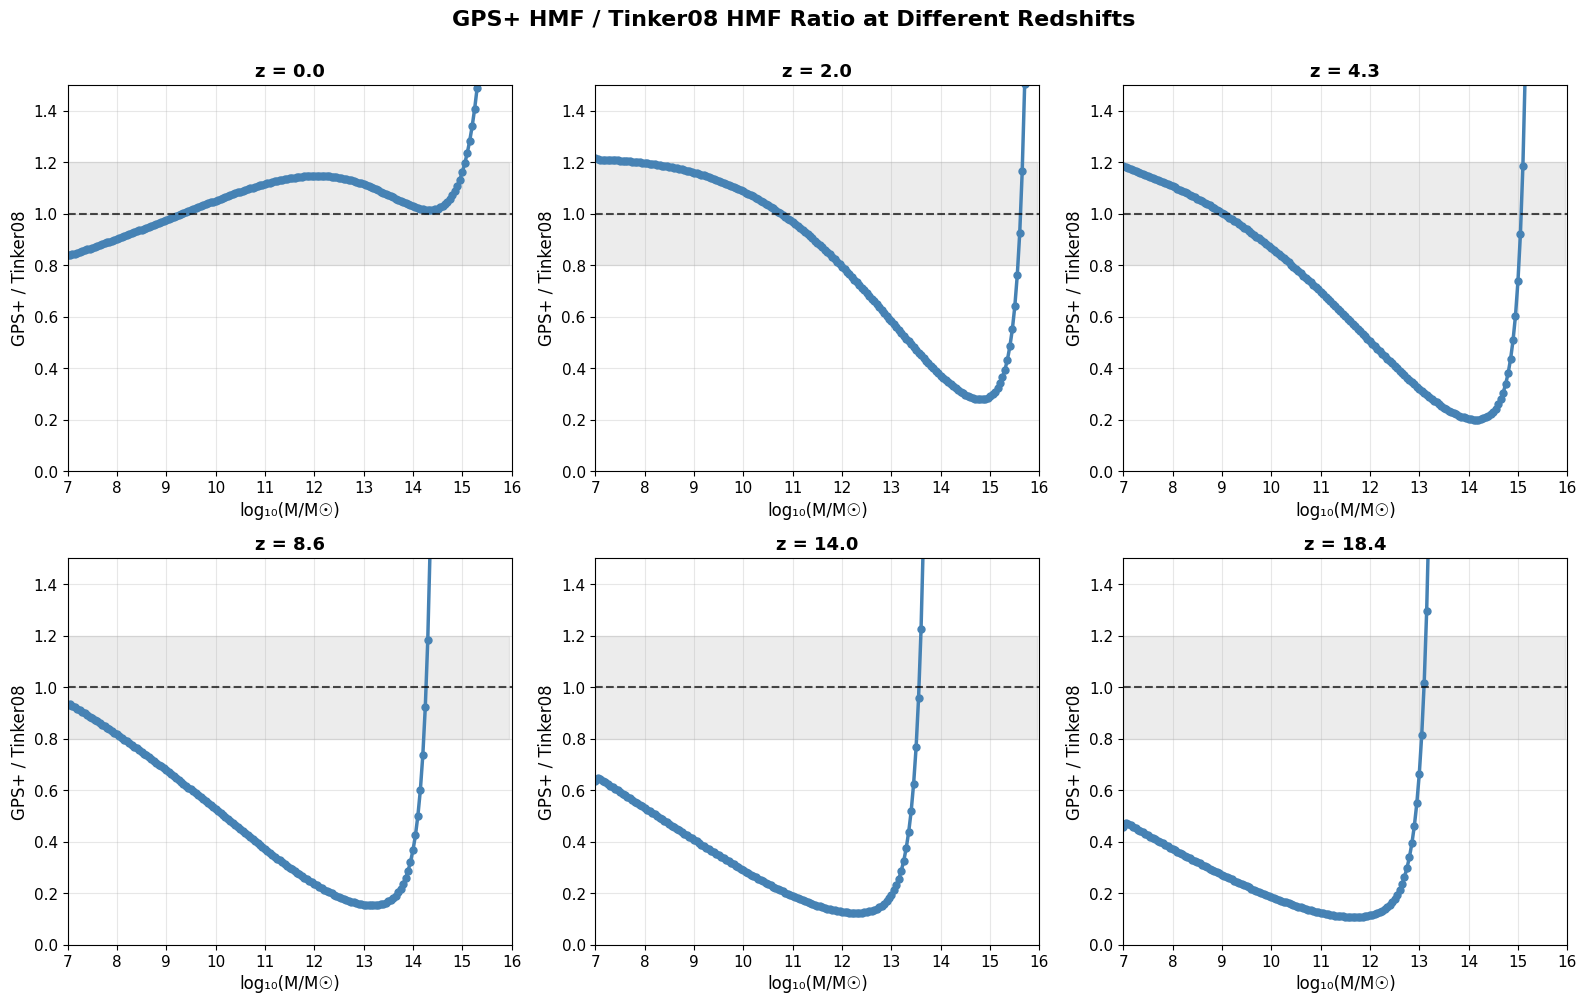

Figure 3: GPS+/Tinker08 HMF ratio across six redshifts
Note: Paper shows GPS+ agreement with Tinker08 to within ~20% (0.8-1.2 range)
Mean ratio: nan, Std: nan


In [ ]:
# Figure 3: Ratio of GPS+ HMF to Tinker08 HMF at six different redshifts
# Shows agreement between GPS+ and Tinker08 across redshift range

# Six redshifts from the paper
redshifts_fig3 = [0.0, 2.03, 4.27, 8.59, 13.96, 18.37]#[0.0, 1.0, 2.0, 3.0, 4.0, 6.0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, z in enumerate(redshifts_fig3):
    ax = axes[idx]
    
    # Compute GPS+ HMF (m200b to match Tinker SOMean-200)
    M_gps, dn_gps = gps_plus_hmf(z=z, mmin=7.0, mmax=16.0, dlog10m=0.05, mdef='m200b')
    
    # Compute Tinker08 HMF at this redshift with SOMean-200 to align mass definition
    hmf_tinker = MassFunction(
        z=z, Mmin=7.0, Mmax=16.0, dlog10m=0.05,
        hmf_model='Tinker08', mdef_model='SOMean',
        mdef_params={'overdensity': 200}
    )
    
    # Get the HMF values for both models
    dn_tinker = hmf_tinker.dndlog10m
    
    # Interpolate to common mass grid if needed
    dn_tinker_interp = np.interp(np.log10(M_gps), np.log10(hmf_tinker.m), dn_tinker)
    ratio = dn_gps / dn_tinker_interp
    
    # Plot ratio vs mass
    log10M = np.log10(M_gps)
    ax.plot(log10M, ratio, 'o-', color='steelblue', lw=2.5, markersize=5)
    
    # Reference line at ratio=1
    ax.axhline(1.0, color='black', ls='--', lw=1.5, alpha=0.7)
    ax.fill_between(log10M, 0.8, 1.2, color='gray', alpha=0.15)
    
    ax.set_xlabel('log₁₀(M/M☉)', fontsize=12)
    ax.set_ylabel('GPS+ / Tinker08', fontsize=12)
    ax.set_title(f'z = {z:.1f}', fontsize=13, fontweight='bold')
    ax.set_xlim([7, 16])
    ax.set_ylim([0, 1.5])
    ax.grid(True, alpha=0.3)

plt.suptitle('GPS+ HMF / Tinker08 HMF Ratio at Different Redshifts', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Figure 3: GPS+/Tinker08 HMF ratio across six redshifts (m200b vs SOMean-200)")
print("Note: GPS+ and Tinker08 comparison uses matched mass definition (mean density).")
print(f"Mean ratio: {np.mean(ratio):.3f}, Std: {np.std(ratio):.3f}")

## Extra: Model Ratios vs Mass at z=0

Compare GPS+ to PS, SMT, and Tinker08 as function of mass

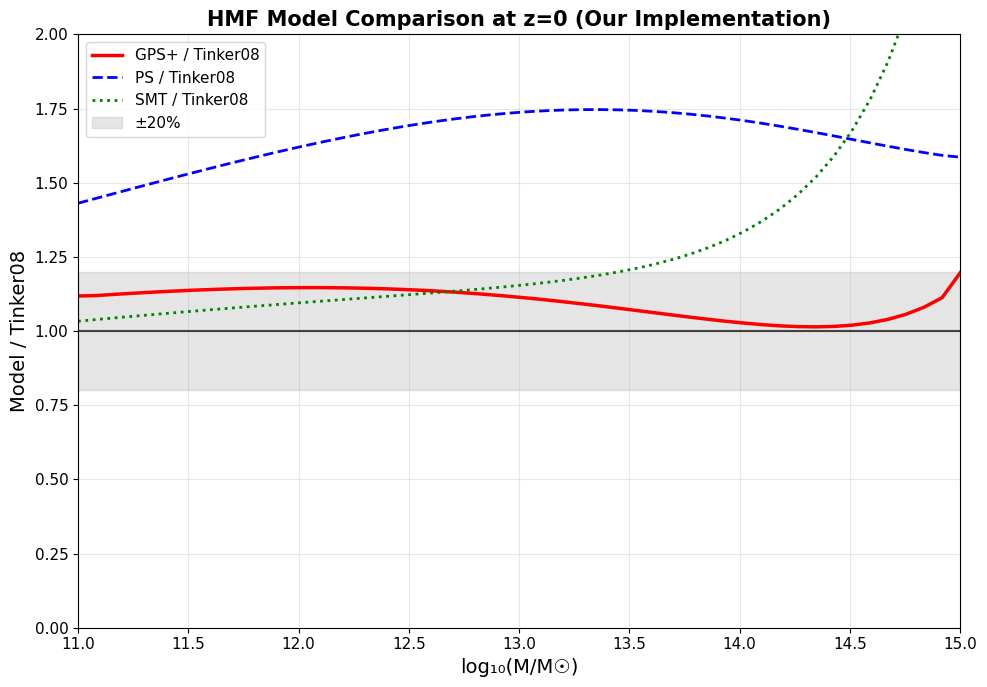

Figure 4: Model ratios vs mass at z=0
GPS+/Tinker08: mean = 1.098, std = 0.048
PS/Tinker08: mean = 1.647, std = 0.088
SMT/Tinker08: mean = 1.312, std = 0.382


In [ ]:
# Figure 4: Ratio of different models to Tinker08 vs mass at z=0

z_fig4 = 0.0
mass_range = np.logspace(11, 15, 50)
log10M_range = np.log10(mass_range)

# Compute GPS+ with m200b to align with Tinker SOMean-200
M_gps, dn_gps_fig4 = gps_plus_hmf(z=z_fig4, mmin=11.0, mmax=15.0, dlog10m=0.02, mdef='m200b')

# Baseline models
hmf_ps = MassFunction(z=z_fig4, Mmin=11.0, Mmax=15.0, dlog10m=0.02, hmf_model='PS')
hmf_smt = MassFunction(z=z_fig4, Mmin=11.0, Mmax=15.0, dlog10m=0.02, hmf_model='SMT')
hmf_tinker = MassFunction(
    z=z_fig4, Mmin=11.0, Mmax=15.0, dlog10m=0.02,
    hmf_model='Tinker08', mdef_model='SOMean',
    mdef_params={'overdensity': 200}
)

# Interpolate all to common mass grid
dn_gps_interp = np.interp(log10M_range, np.log10(M_gps), dn_gps_fig4)
dn_ps_interp = np.interp(log10M_range, np.log10(hmf_ps.m), hmf_ps.dndlog10m)
dn_smt_interp = np.interp(log10M_range, np.log10(hmf_smt.m), hmf_smt.dndlog10m)
dn_tinker_interp = np.interp(log10M_range, np.log10(hmf_tinker.m), hmf_tinker.dndlog10m)

# Compute ratios
ratio_gps_tinker = dn_gps_interp / dn_tinker_interp
ratio_ps_tinker = dn_ps_interp / dn_tinker_interp
ratio_smt_tinker = dn_smt_interp / dn_tinker_interp

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(log10M_range, ratio_gps_tinker, 'r-', lw=2.5, label='GPS+ / Tinker08 (m200b vs SOMean-200)')
ax.plot(log10M_range, ratio_ps_tinker, 'b--', lw=2, label='PS / Tinker08')
ax.plot(log10M_range, ratio_smt_tinker, 'g:', lw=2, label='SMT / Tinker08')

# Reference lines
ax.axhline(1.0, color='black', ls='-', lw=1.5, alpha=0.7)
ax.fill_between([11, 15], 0.8, 1.2, color='gray', alpha=0.2, label='±20%')

ax.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax.set_ylabel('Model / Tinker08', fontsize=14)
ax.set_title('HMF Model Comparison at z=0 (Aligned Mass Definitions)', fontsize=15, fontweight='bold')
ax.set_xlim([11, 15])
ax.set_ylim([0, 2.0])
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Figure 4: Model ratios vs mass at z=0 (SOMean-200 baseline)")
print(f"GPS+/Tinker08: mean = {np.mean(ratio_gps_tinker):.3f}, std = {np.std(ratio_gps_tinker):.3f}")
print(f"PS/Tinker08: mean = {np.mean(ratio_ps_tinker):.3f}, std = {np.std(ratio_ps_tinker):.3f}")
print(f"SMT/Tinker08: mean = {np.mean(ratio_smt_tinker):.3f}, std = {np.std(ratio_smt_tinker):.3f}")

## Extended Figure: Redshift Evolution of GPS+

Show how GPS+ HMF evolves with redshift for several mass scales

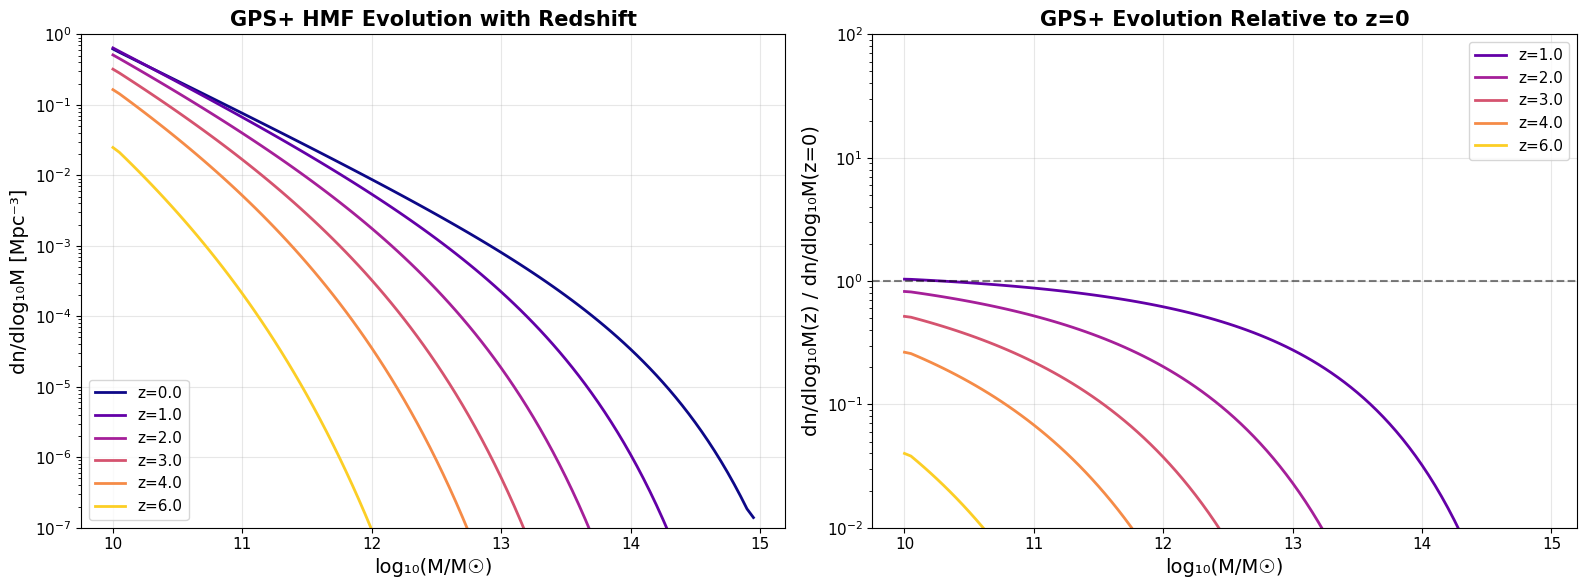

Extended Figure: GPS+ redshift evolution
Shows characteristic evolution: higher z → fewer massive halos


In [ ]:
# Extended: GPS+ evolution with redshift

redshifts_ext = [0.0, 1.0, 2.0, 3.0, 4.0, 6.0]
colors_ext = plt.cm.plasma(np.linspace(0, 0.9, len(redshifts_ext)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Absolute HMF
for z, color in zip(redshifts_ext, colors_ext):
    M_z, dn_z = gps_plus_hmf(z=z, mmin=10.0, mmax=15.0, dlog10m=0.05, mdef='m200b')
    ax1.plot(np.log10(M_z), dn_z, color=color, lw=2, label=f'z={z:.1f}')

ax1.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax1.set_ylabel('dn/dlog₁₀M [Mpc⁻³]', fontsize=14)
ax1.set_title('GPS+ HMF Evolution with Redshift', fontsize=15, fontweight='bold')
ax1.set_yscale('log')
ax1.set_ylim([1e-7, 1e0])
ax1.legend(loc='lower left', fontsize=11)
ax1.grid(True, alpha=0.3)

# Right panel: Ratio to z=0
M_z0, dn_z0 = gps_plus_hmf(z=0.0, mmin=10.0, mmax=15.0, dlog10m=0.05, mdef='m200b')
log10M_z0 = np.log10(M_z0)

for z, color in zip(redshifts_ext[1:], colors_ext[1:]):  # Skip z=0
    M_z, dn_z = gps_plus_hmf(z=z, mmin=10.0, mmax=15.0, dlog10m=0.05, mdef='m200b')
    
    # Interpolate to z=0 grid
    dn_z_interp = np.interp(log10M_z0, np.log10(M_z), dn_z)
    ratio = dn_z_interp / dn_z0
    
    ax2.plot(log10M_z0, ratio, color=color, lw=2, label=f'z={z:.1f}')

ax2.axhline(1.0, color='black', ls='--', lw=1.5, alpha=0.5)
ax2.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax2.set_ylabel('dn/dlog₁₀M(z) / dn/dlog₁₀M(z=0)', fontsize=14)
ax2.set_title('GPS+ Evolution Relative to z=0', fontsize=15, fontweight='bold')
ax2.set_yscale('log')
ax2.set_ylim([1e-2, 1e2])
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Extended Figure: GPS+ redshift evolution (HMF_GPSplus)")
print("Shows characteristic evolution: higher z → fewer massive halos")